#### Ackowledgement

I acknowledge that I used AI assistance while working on this Python implementation. I also referred to the in-class R code provided during lectures to better understand and guide the development of this solution.
All work has been completed with my own understanding, incorporating these resources as supportive references.

1. Setup and data loading

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [3]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(url)
raw.shape  # expect ~7214 rows


(7214, 53)

2. Keeping the same variables in R and filtering

In [4]:
cols = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]
df = raw[cols].copy()
df.shape


(7214, 13)

In [5]:
df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]

df = df[df["is_recid"] != -1]

df = df[df["c_charge_degree"] != "O"]

df = df[~df["score_text"].isna()]

df.shape

(6172, 13)

In [6]:
df.head()


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30


In [7]:
df.describe(include="all")

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out
count,6172.000000,6172,6172,6172,6172,6172,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172,6172
unique,NaN,2,6,3,3,2,NaN,NaN,NaN,NaN,NaN,6172,6161
top,NaN,F,African-American,25 - 45,Low,Male,NaN,NaN,NaN,NaN,NaN,2014-06-28 12:16:41,2013-09-14 05:58:00
freq,NaN,3970,3175,3532,3421,4997,NaN,NaN,NaN,NaN,NaN,1,3
mean,34.534511,NaN,NaN,NaN,NaN,NaN,3.246436,-1.740279,4.418503,0.484446,0.455120,NaN,NaN
std,11.730938,NaN,NaN,NaN,NaN,NaN,4.743770,5.084709,2.839463,0.499799,0.498022,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-30.000000,1.000000,0.000000,0.000000,NaN,NaN
25%,25.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-1.000000,2.000000,0.000000,0.000000,NaN,NaN
50%,31.000000,NaN,NaN,NaN,NaN,NaN,1.000000,-1.000000,4.000000,0.000000,0.000000,NaN,NaN
75%,42.000000,NaN,NaN,NaN,NaN,NaN,4.000000,-1.000000,7.000000,1.000000,1.000000,NaN,NaN


Optional plots:

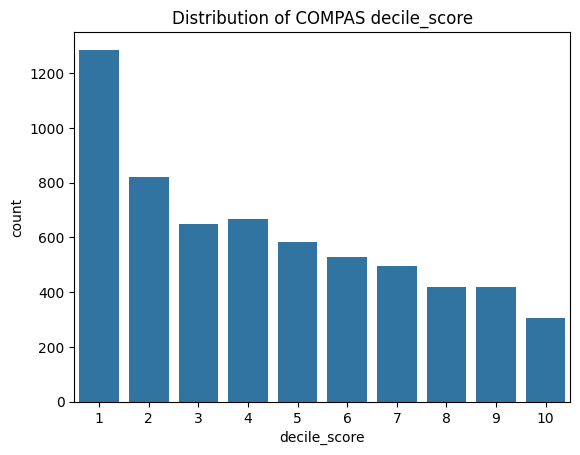

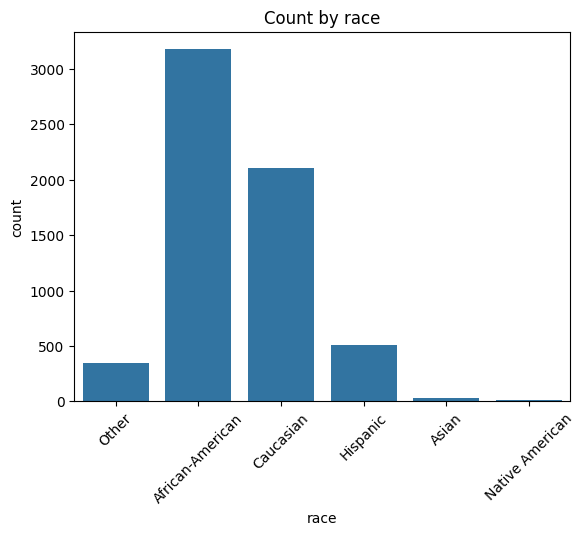

In [8]:
sns.countplot(x="decile_score", data=df)
plt.title("Distribution of COMPAS decile_score")
plt.show()

sns.countplot(x="race", data=df)
plt.title("Count by race")
plt.xticks(rotation=45)
plt.show()


3. Creating derived factors like in R
(The R code creates factors with reference levels, and a binary risk flag based on decile_score ≥ 7.)

In [9]:
df["crime_factor"] = df["c_charge_degree"].astype("category")

age_cat = pd.Categorical(
    df["age_cat"],
    categories=["Less than 25", "25 - 45", "Greater than 45"],
    ordered=True
)
df["age_factor"] = age_cat

race_cat = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Hispanic", "Asian", "Native American", "Other"],
    ordered=False
)
df["race_factor"] = race_cat

sex_cat = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"],
    ordered=False
)
df["gender_factor"] = sex_cat

df["score_factor"] = np.where(df["score_text"] == "Low", "LowScore", "HighScore")
df["score_factor"] = df["score_factor"].astype("category")

df["two_year_recid"] = df["two_year_recid"].astype(int)


In [10]:
df[["age_factor", "race_factor", "gender_factor", "crime_factor", "score_factor"]].head()


,age_factor,race_factor,gender_factor,crime_factor,score_factor
0,Greater than 45,Other,Male,F,LowScore
1,25 - 45,African-American,Male,F,LowScore
2,Less than 25,African-American,Male,F,LowScore
5,25 - 45,Other,Male,M,LowScore
6,25 - 45,Caucasian,Male,F,HighScore


4. Logistic regression (score_factor ~ gender + age + race + priors + crime + two_year_recid)
###### This mirrors the R formula: `score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid`

###### We’ll model “HighScore” vs “LowScore” via a logistic regression.

In [11]:
df["score_binary"] = np.where(df["score_factor"] == "HighScore", 1, 0)

formula = "score_binary ~ C(gender_factor) + C(age_factor) + C(race_factor) + priors_count + C(crime_factor) + two_year_recid"

model = smf.logit(formula=formula, data=df).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        04:11:36   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -0.2171      0.088    

5. Predictions and overall confusion matrix

In [12]:
df["pred_prob"] = model.predict(df)
df["pred_class"] = (df["pred_prob"] >= 0.5).astype(int)  # 1 = HighScore predicted

cm = confusion_matrix(df["score_binary"], df["pred_class"])
cm


array([[2744,  677],
       [ 854, 1897]])

In [13]:
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

accuracy, precision, recall, fpr, fnr


(np.float64(0.7519442644199611),
 np.float64(0.736985236985237),
 np.float64(0.6895674300254453),
 np.float64(0.19789535223618826),
 np.float64(0.3104325699745547))

6. Group-conditional confusion matrices and fairness metrics.
This follows the slides’ step where they compute FPR/FNR by race and then disparities.

In [14]:
metrics_rows = []

for race in df["race_factor"].cat.categories:
    sub = df[df["race_factor"] == race]
    if sub.empty:
        continue

    cm_r = confusion_matrix(sub["score_binary"], sub["pred_class"])
    if cm_r.shape == (2, 2):
        tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
    else:
        tn_r = fp_r = fn_r = tp_r = np.nan

    n = len(sub)
    accuracy_r = (tp_r + tn_r) / n if n > 0 else np.nan
    precision_r = tp_r / (tp_r + fp_r) if (tp_r + fp_r) > 0 else np.nan
    recall_r = tp_r / (tp_r + fn_r) if (tp_r + fn_r) > 0 else np.nan
    fpr_r = fp_r / (fp_r + tn_r) if (fp_r + tn_r) > 0 else np.nan
    fnr_r = fn_r / (fn_r + tp_r) if (fn_r + tp_r) > 0 else np.nan

    metrics_rows.append({
        "race": race,
        "n": n,
        "TP": tp_r,
        "TN": tn_r,
        "FP": fp_r,
        "FN": fn_r,
        "Accuracy": round(accuracy_r, 3) if not np.isnan(accuracy_r) else np.nan,
        "Precision": round(precision_r, 3) if not np.isnan(precision_r) else np.nan,
        "Recall": round(recall_r, 3) if not np.isnan(recall_r) else np.nan,
        "FPR": round(fpr_r, 3) if not np.isnan(fpr_r) else np.nan,
        "FNR": round(fnr_r, 3) if not np.isnan(fnr_r) else np.nan,
    })

race_metrics = pd.DataFrame(metrics_rows).sort_values("n", ascending=False)
race_metrics


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
1,African-American,3175,1445,863,483,384,0.727,0.749,0.790,0.359,0.210
0,Caucasian,2103,358,1251,156,338,0.765,0.696,0.514,0.111,0.486
2,Hispanic,509,65,338,30,76,0.792,0.684,0.461,0.082,0.539
5,Other,343,18,266,7,52,0.828,0.720,0.257,0.026,0.743
3,Asian,31,3,24,0,4,0.871,1.000,0.429,0.000,0.571
4,Native American,11,8,2,1,0,0.909,0.889,1.000,0.333,0.000


In [15]:
ref = "Caucasian"
ref_row = race_metrics[race_metrics["race"] == ref].iloc[0]

race_metrics["delta_FPR_vs_Caucasian"] = race_metrics["FPR"] - ref_row["FPR"]
race_metrics["delta_FNR_vs_Caucasian"] = race_metrics["FNR"] - ref_row["FNR"]

race_metrics


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR,delta_FPR_vs_Caucasian,delta_FNR_vs_Caucasian
1,African-American,3175,1445,863,483,384,0.727,0.749,0.790,0.359,0.210,0.248,-0.276
0,Caucasian,2103,358,1251,156,338,0.765,0.696,0.514,0.111,0.486,0.000,0.000
2,Hispanic,509,65,338,30,76,0.792,0.684,0.461,0.082,0.539,-0.029,0.053
5,Other,343,18,266,7,52,0.828,0.720,0.257,0.026,0.743,-0.085,0.257
3,Asian,31,3,24,0,4,0.871,1.000,0.429,0.000,0.571,-0.111,0.085
4,Native American,11,8,2,1,0,0.909,0.889,1.000,0.333,0.000,0.222,-0.486


7. Basic calibration

In [16]:
calib = (
    df.groupby(["decile_score", "race_factor"])
      .agg(
          mean_score=("score_binary", "mean"),
          mean_recid=("two_year_recid", "mean"),
          n=("two_year_recid", "size")
      )
      .reset_index()
)

calib.head()


/tmp/ipykernel_8835/918755385.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["decile_score", "race_factor"])


,decile_score,race_factor,mean_score,mean_recid,n
0,1,Caucasian,0.0,0.211570,605
1,1,African-American,0.0,0.232877,365
2,1,Hispanic,0.0,0.238994,159
3,1,Asian,0.0,0.066667,15
4,1,Native American,NaN,NaN,0


### **Extra imports and installing libraries**


In [17]:
get_ipython().system('pip install lime')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3e57a8502a36c41e6a760ba31385afc7979dc11ba74315cf0c24f4aa34cbbb8c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [18]:
get_ipython().system('pip install dice_ml')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.4 MB/s eta 0:00:00


In [19]:
# extra imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

import shap
from lime.lime_tabular import LimeTabularExplainer

import dice_ml
from dice_ml import Dice

**1. Defining features and train/test split.**

We’ll use two_year_recid as the target and keep features consistent with HW1 analysis: `age`, `priors_count`, `decile_score`, `days_b_screening_arrest` (numeric) and `race`, `sex`, `c_charge_degree`, `age_cat` (categorical)

In [20]:
y = df["two_year_recid"].astype(int).values

numeric_features = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
categorical_features = ["race", "sex", "c_charge_degree", "age_cat"]

X = df[numeric_features + categorical_features].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (4937, 8) Test shape: (1235, 8)


**2. Preprocessor and Gradient-Boosted Tree “replacement model”**

In [21]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

gbt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            random_state=42
        ))
    ]
)

gbt_pipeline.fit(X_train, y_train)
print("Replacement GBT model trained.")

Replacement GBT model trained.


**Checking performance by race:**

In [22]:
def group_metrics(pipeline, X, y, group_col="race"):
    X_local = X.copy()
    y_pred = pipeline.predict(X_local)
    y_prob = pipeline.predict_proba(X_local)[:, 1]
    X_local["actual"] = y
    X_local["pred"] = y_pred
    X_local["pred_prob"] = y_prob

    rows = []
    for group, gdf in X_local.groupby(group_col):
        # Ensure confusion matrix is always 2x2 by explicitly defining labels [0, 1]
        cm = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        n = len(gdf)
        acc = round(accuracy_score(gdf["actual"], gdf["pred"]), 3)
        fpr = round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan
        fnr = round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan
        auc = round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3)

        rows.append({
            "race": group,
            "n": n,
            "Accuracy": acc,
            "FPR": fpr,
            "FNR": fnr,
            "AUC": auc
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)

print("GBT group metrics by race on test set:")
group_metrics(gbt_pipeline, X_test, y_test)

GBT group metrics by race on test set:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,race,n,Accuracy,FPR,FNR,AUC
0,African-American,641,0.686,0.319,0.309,0.746
2,Caucasian,427,0.698,0.147,0.559,0.709
3,Hispanic,94,0.617,0.163,0.622,0.637
5,Other,65,0.692,0.128,0.778,0.703
1,Asian,7,0.714,0.167,1.000,0.667
4,Native American,1,1.000,0.000,NaN,NaN


**3. SHAP: beeswarm + waterfall (highest/lowest risk per race)**


In [23]:
X_test_enc = gbt_pipeline.named_steps["preprocessor"].transform(X_test)

ohe = gbt_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
feature_names = numeric_features + cat_feature_names

explainer = shap.Explainer(
    gbt_pipeline.named_steps["classifier"],
    shap.maskers.Independent(X_test_enc)
)

shap_values = explainer(X_test_enc, check_additivity=False)

 99%|===================| 1217/1235 [00:13<00:00]       

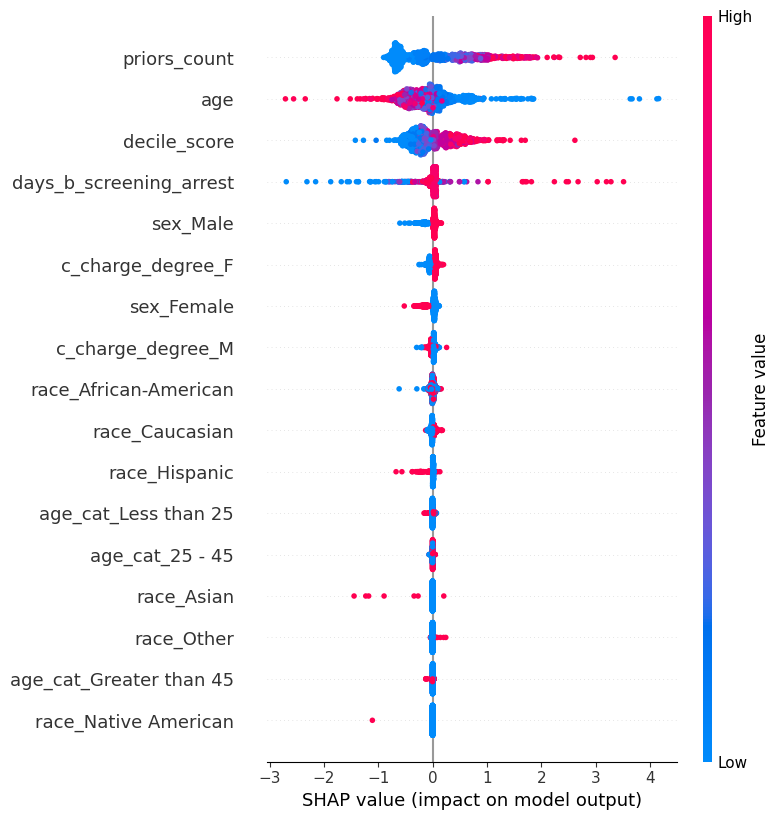

In [24]:
shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=feature_names,
    show=True
)

In [25]:
y_proba_test = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_proba"] = y_proba_test

selected_indices = []

for race in X_test_copy["race"].unique():
    sub = X_test_copy[X_test_copy["race"] == race]
    if sub.empty:
        continue
    high_idx = sub["pred_proba"].idxmax()
    low_idx = sub["pred_proba"].idxmin()
    selected_indices.extend([high_idx, low_idx])

# keep unique order
selected_indices = list(dict.fromkeys(selected_indices))
selected_indices

[np.int64(5910),
 np.int64(4073),
 np.int64(6293),
 np.int64(5656),
 np.int64(1794),
 np.int64(2849),
 np.int64(5770),
 np.int64(3007),
 np.int64(4413),
 np.int64(3093),
 np.int64(1476)]

**4. LIME: explanations for the same individuals**


In [26]:
X_train_enc = gbt_pipeline.named_steps["preprocessor"].fit_transform(X_train)

explainer_lime = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def predict_fn_lime(X_enc):
    return gbt_pipeline.named_steps["classifier"].predict_proba(X_enc)


In [27]:
for idx in selected_indices:
    loc = X_test.index.get_loc(idx)
    row_enc = X_test_enc[loc]

    exp = explainer_lime.explain_instance(
        data_row=row_enc,
        predict_fn=predict_fn_lime,
        num_features=6
    )

    print(f"\nLIME explanation – idx {idx}, race={X_test.loc[idx, 'race']}, "
          f"proba={X_test_copy.loc[idx, 'pred_proba']:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat}: {weight:.4f}")


LIME explanation – idx 5910, race=Hispanic, proba=0.921
  days_b_screening_arrest <= 0.15: -0.3345
  race_Asian <= 0.00: 0.2220
  decile_score > 0.89: 0.1721
  age <= -0.81: 0.1516
  -0.48 < priors_count <= 0.16: -0.0458
  sex_Female <= 0.00: 0.0379

LIME explanation – idx 4073, race=Hispanic, proba=0.013
  days_b_screening_arrest <= 0.15: -0.3358
  -0.69 < priors_count <= -0.48: -0.1649
  race_Asian <= 0.00: 0.1539
  age > 0.56: -0.1194
  decile_score <= -0.86: -0.0886
  race_Hispanic > 0.00: -0.0404

LIME explanation – idx 6293, race=African-American, proba=0.997
  days_b_screening_arrest > 0.15: 0.3305
  age <= -0.81: 0.1449
  race_Asian <= 0.00: 0.1219
  -0.48 < priors_count <= 0.16: -0.0483
  race_Hispanic <= 0.00: 0.0416
  sex_Female <= 0.00: 0.0363

LIME explanation – idx 5656, race=African-American, proba=0.041
  days_b_screening_arrest <= 0.15: -0.3440
  race_Asian <= 0.00: 0.2146
  decile_score > 0.89: 0.1625
  -0.69 < priors_count <= -0.48: -0.1534
  -0.81 < age <= -0.29: 0

**Agreements between LIME and SHAP**

- Both methods explain individual predictions by assigning feature importance scores.

- For high predicted recidivism, both consistently flagged higher priors_count and higher days_b_screening_arrest as key drivers of risk, while low values of these features contributed to low‑risk predictions.

- Both also showed meaningful effects for age and decile_score, even if the exact cut‑points differed.


**Divergences between LIME and SHAP**

- SHAP offers a global view (via the beeswarm plot) in addition to local explanations, while LIME is strictly local to a single instance.

- SHAP displays explicit one‑hot categories (e.g., race_African-American), whereas LIME often uses conditions like race_Hispanic <= 0.00, which indirectly encode the absence/presence of a category and can be harder to interpret.

- SHAP plots encode both magnitude and direction visually; LIME returns a simple list of feature–weight pairs that is easier to read but less informative about overall behavior.

**Governance implications**

- Used together, LIME and SHAP help surface potential bias, for example if race‑related features repeatedly drive higher risk scores for certain groups.

- They increase transparency around the Gradient Boosting model’s behavior, supporting accountability and enabling stakeholders to see why an individual received a given risk label.

- Disagreements or surprising attributions can reveal proxy features (such as strongly race‑correlated variables), suggesting a need for model revision or additional fairness constraints.

- DiCE complements these tools by showing actionable counterfactual changes in mutable features and highlighting problematic counterfactuals that rely on changing immutable attributes such as race or sex.

**5. DiCE: counterfactuals & immutable-feature checks**

In [28]:
train_for_dice = X_train.copy()
train_for_dice["target"] = y_train

continuous_features = numeric_features
outcome_name = "target"

data_dice = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=continuous_features,
    outcome_name=outcome_name
)

model_dice = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(
    data_dice,
    model_dice,
    method="random"
)

In [29]:
immutable_features = ["race", "sex"]

for idx in selected_indices:
    query_instance = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query_instance,
        total_CFs=3,
        desired_class="opposite",
        features_to_vary="all"
    )

    print(f"\nDiCE counterfactuals – idx {idx}, race={X_test.loc[idx, 'race']}, "
          f"proba={X_test_copy.loc[idx, 'pred_proba']:.3f}")

    df_cf = cf.cf_examples_list[0].final_cfs_df
    print(df_cf)

    original = query_instance.iloc[0]
    for i, row in df_cf.iterrows():
        changed_immutables = [
            col for col in immutable_features
            if col in row.index and row[col] != original[col]
        ]
        if changed_immutables:
            print(f"  WARNING: CF {i} changes immutable features: {changed_immutables}")

100%|██████████| 1/1 [00:00<00:00,  6.68it/s]



DiCE counterfactuals – idx 5910, race=Hispanic, proba=0.921
   age  priors_count  days_b_screening_arrest  decile_score      race     sex  \
0   44             2                     -1.0             8  Hispanic  Female   
1   64             2                     -1.0             8  Hispanic    Male   
2   27             2                     -1.0             8  Hispanic    Male   

  c_charge_degree       age_cat  target  
0               F  Less than 25       0  
1               M  Less than 25       0  
2               F  Less than 25       0  


100%|██████████| 1/1 [00:00<00:00,  6.63it/s]



DiCE counterfactuals – idx 4073, race=Hispanic, proba=0.013
   age  priors_count  days_b_screening_arrest  decile_score      race     sex  \
0   47             1                      8.7             1  Hispanic    Male   
1   47            31                    -27.0             1  Hispanic  Female   
2   47            28                    -27.0             5  Hispanic    Male   

  c_charge_degree          age_cat  target  
0               F  Greater than 45       1  
1               F  Greater than 45       1  
2               F  Greater than 45       1  


100%|██████████| 1/1 [00:00<00:00,  7.40it/s]


...


DiCE counterfactuals – idx 4413, race=Caucasian, proba=0.997
   age  priors_count  days_b_screening_arrest  decile_score       race  \
0   89             1                     28.0             9  Caucasian   
1   66             1                     28.0             9  Caucasian   
2   20             1                    -26.2             9   Hispanic   

      sex c_charge_degree       age_cat  target  
0    Male               F  Less than 25       0  
1  Female               F  Less than 25       0  
2    Male               F  Less than 25       0  


100%|██████████| 1/1 [00:00<00:00,  5.61it/s]



DiCE counterfactuals – idx 3093, race=Caucasian, proba=0.017
   age  priors_count  days_b_screening_arrest  decile_score       race   sex  \
0   69             1                    -29.0             7  Caucasian  Male   
1   39             1                     27.7             1  Caucasian  Male   
2   39             6                    -29.4             1  Caucasian  Male   

  c_charge_degree  age_cat  target  
0               F  25 - 45       1  
1               F  25 - 45       1  
2               F  25 - 45       1  


100%|██████████| 1/1 [00:00<00:00,  4.78it/s]


DiCE counterfactuals – idx 1476, race=Native American, proba=0.176
   age  priors_count  days_b_screening_arrest  decile_score             race  \
0   39            30                     -1.0             3  Native American   
1   95            35                     -1.0             3  Native American   
2   28             2                     23.2             3  Native American   

    sex c_charge_degree  age_cat  target  
0  Male               F  25 - 45       1  
1  Male               F  25 - 45       1  
2  Male               M  25 - 45       1  


#### **Installing Required Packages and Importing Libraries**

In [30]:
!pip install solas-ai

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

#### Basic Data Check

In [41]:
print(df.columns)


Index(['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
       'priors_count', 'days_b_screening_arrest', 'decile_score', 'is_recid',
       'two_year_recid', 'c_jail_in', 'c_jail_out', 'crime_factor',
       'age_factor', 'race_factor', 'gender_factor', 'score_factor',
       'score_binary', 'pred_prob', 'pred_class', 'is_african_american',
       'is_caucasian', 'y_true'],
      dtype='object')


#### Setting up outcome, predictions, and helper functions

In [42]:
df["y_true"] = df["two_year_recid"].astype(int)

formula_hw3 = "y_true ~ C(age_factor) + C(race_factor) + C(gender_factor) + C(crime_factor) + priors_count"
model_hw3 = smf.logit(formula=formula_hw3, data=df).fit(disp=False)
print(model_hw3.summary())

df["pred_prob"] = model_hw3.predict(df)
df["pred_class"] = (df["pred_prob"] >= 0.5).astype(int)

df[["y_true", "pred_prob", "pred_class"]].head()

                           Logit Regression Results                           
Dep. Variable:                 y_true   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6161
Method:                           MLE   Df Model:                           10
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.1094
Time:                        04:23:51   Log-Likelihood:                -3788.1
converged:                       True   LL-Null:                       -4253.2
Covariance Type:            nonrobust   LLR p-value:                1.984e-193
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              0.1252      0.075      1.666      0.096      -0.022       0.272
C(age_factor)[T.25 - 45]              -0.7335      0.069   

,y_true,pred_prob,pred_class
0,0,0.192877,0
1,1,0.374649,0
2,1,0.707511,1
5,0,0.272510,0
6,1,0.846745,1


In [43]:
def selection_rate(data, outcome_col):
    return data[outcome_col].mean()

def adverse_impact_ratio_manual(data, group_col, outcome_col, protected_group, reference_group):
    sr_protected = selection_rate(data[data[group_col] == protected_group], outcome_col)
    sr_reference = selection_rate(data[data[group_col] == reference_group], outcome_col)
    air = np.nan if sr_reference == 0 else sr_protected / sr_reference
    return air, sr_protected, sr_reference

def marginal_effect_manual(data, group_col, outcome_col, protected_group, reference_group):
    sr_protected = selection_rate(data[data[group_col] == protected_group], outcome_col)
    sr_reference = selection_rate(data[data[group_col] == reference_group], outcome_col)
    me = sr_protected - sr_reference
    return me, sr_protected, sr_reference

def standardized_mean_difference_manual(data, group_col, score_col, protected_group, reference_group):
    x1 = data.loc[data[group_col] == protected_group, score_col].dropna()
    x0 = data.loc[data[group_col] == reference_group, score_col].dropna()
    m1, m0 = x1.mean(), x0.mean()
    s1, s0 = x1.std(ddof=1), x0.std(ddof=1)
    pooled = np.sqrt((s1**2 + s0**2) / 2)
    smd = np.nan if pooled == 0 else (m1 - m0) / pooled
    return smd, m1, m0

def confusion_stats(data, truth_col, pred_col):
    tn, fp, fn, tp = confusion_matrix(data[truth_col], data[pred_col], labels=[0, 1]).ravel()
    acc = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    return {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Accuracy": acc, "Precision": precision, "Recall": recall,
        "FPR": fpr, "FNR": fnr
    }

def group_confusion_table(data, group_col, truth_col, pred_col):
    rows = []
    for g, sub in data.groupby(group_col, observed=False):
        stats = confusion_stats(sub, truth_col, pred_col)
        rows.append({group_col: g, "n": len(sub), **stats})
    return pd.DataFrame(rows)

from statsmodels.stats.proportion import proportions_ztest

def two_prop_test(success1, total1, success0, total0):
    if total1 == 0 or total0 == 0:
        return np.nan, np.nan
    stat, pval = proportions_ztest(count=[success1, success0], nobs=[total1, total0])
    return stat, pval

#### Manual AIR, ME, SMD for race and sex

In [44]:
air_race, sr_p_race, sr_r_race = adverse_impact_ratio_manual(
    df, "race_factor", "pred_class", "African-American", "Caucasian"
)
me_race, _, _ = marginal_effect_manual(
    df, "race_factor", "pred_class", "African-American", "Caucasian"
)
smd_race, m1_race, m0_race = standardized_mean_difference_manual(
    df, "race_factor", "pred_prob", "African-American", "Caucasian"
)

air_sex, sr_p_sex, sr_r_sex = adverse_impact_ratio_manual(
    df, "gender_factor", "pred_class", "Female", "Male"
)
me_sex, _, _ = marginal_effect_manual(
    df, "gender_factor", "pred_class", "Female", "Male"
)
smd_sex, m1_sex, m0_sex = standardized_mean_difference_manual(
    df, "gender_factor", "pred_prob", "Female", "Male"
)

manual_compare = pd.DataFrame([
    {
        "attribute": "race",
        "protected": "African-American",
        "reference": "Caucasian",
        "AIR": air_race,
        "ME": me_race,
        "SMD": smd_race
    },
    {
        "attribute": "sex",
        "protected": "Female",
        "reference": "Male",
        "AIR": air_sex,
        "ME": me_sex,
        "SMD": smd_sex
    }
])

manual_compare

,attribute,protected,reference,AIR,ME,SMD
0,race,African-American,Caucasian,2.069882,0.272685,0.76491
1,sex,Female,Male,0.321768,-0.297787,-0.75148


#### solas-ai disparity metrics

In [46]:
import solas_disparity as sd

def safe_solas_call(metric_name, **kwargs):
    try:
        fn = getattr(sd, metric_name)
        return fn(**kwargs)
    except Exception as e:
        print(f"ERROR in {metric_name}:", e)
        return None

air_race_solas = safe_solas_call(
    "adverse_impact_ratio",
    group_data=df,
    protected_groups=["African-American"],
    reference_groups=["Caucasian"],
    group_categories=["race_factor"],
    outcome=df["pred_class"],
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0.0
)

me_race_solas = safe_solas_call(
    "marginal_effect",
    group_data=df,
    protected_groups=["African-American"],
    reference_groups=["Caucasian"],
    group_categories=["race_factor"],
    outcome=df["pred_class"],
    sample_weight=None
)

smd_race_solas = safe_solas_call(
    "standardized_mean_difference",
    group_data=df,
    protected_groups=["African-American"],
    reference_groups=["Caucasian"],
    group_categories=["race_factor"],
    score=df["pred_prob"],
    sample_weight=None
)

air_sex_solas = safe_solas_call(
    "adverse_impact_ratio",
    group_data=df,
    protected_groups=["Female"],
    reference_groups=["Male"],
    group_categories=["gender_factor"],
    outcome=df["pred_class"],
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0.0
)

me_sex_solas = safe_solas_call(
    "marginal_effect",
    group_data=df,
    protected_groups=["Female"],
    reference_groups=["Male"],
    group_categories=["gender_factor"],
    outcome=df["pred_class"],
    sample_weight=None
)

smd_sex_solas = safe_solas_call(
    "standardized_mean_difference",
    group_data=df,
    protected_groups=["Female"],
    reference_groups=["Male"],
    group_categories=["gender_factor"],
    score=df["pred_prob"],
    sample_weight=None
)

air_race_solas, me_race_solas, smd_race_solas, air_sex_solas, me_sex_solas, smd_sex_solas

ERROR in adverse_impact_ratio: "None of [Index(['African-American', 'Caucasian'], dtype='object')] are in the [columns]"
ERROR in marginal_effect: module 'solas_disparity' has no attribute 'marginal_effect'
ERROR in standardized_mean_difference: 3 validation errors for StandardizedMeanDifference
outcome
  field required (type=value_error.missing)
smd_threshold
  field required (type=value_error.missing)
kwargs
  unexpected keyword argument: 'score' (type=type_error)
ERROR in adverse_impact_ratio: "None of [Index(['Female', 'Male'], dtype='object')] are in the [columns]"
ERROR in marginal_effect: module 'solas_disparity' has no attribute 'marginal_effect'
ERROR in standardized_mean_difference: 3 validation errors for StandardizedMeanDifference
outcome
  field required (type=value_error.missing)
smd_threshold
  field required (type=value_error.missing)
kwargs
  unexpected keyword argument: 'score' (type=type_error)


(None, None, None, None, None, None)

#### Intersectional AIR: race x sex

In [50]:

df["race_sex"] = df["race_factor"].astype(str) + " | " + df["gender_factor"].astype(str)

intersection_summary = (
    df.groupby("race_sex", observed=False)
      .agg(
          n=("pred_class", "size"),
          selection_rate=("pred_class", "mean"),
          mean_pred_prob=("pred_prob", "mean")
      )
      .reset_index()
)

ref_group = "Caucasian | Male"
ref_rate = intersection_summary.loc[intersection_summary["race_sex"] == ref_group, "selection_rate"].iloc[0]

intersection_summary["AIR_vs_Caucasian_Male"] = intersection_summary["selection_rate"] / ref_rate
intersection_summary = intersection_summary.sort_values("AIR_vs_Caucasian_Male", ascending=True).reset_index(drop=True)

In [51]:
worst_group = intersection_summary.iloc[0]
worst_group["race_sex"], worst_group["AIR_vs_Caucasian_Male"]

('Asian | Female', np.float64(0.0))

The subgroup Asian | Female has an AIR of 0.0 relative to the reference group (Caucasian | Male).

AIR 0.0 implies that no Asian women in the sample were ever classified as positive by the model, while some Caucasian men were.

Under the 80% rule, this is an extreme disparate impact signal: the selection rate for Asian women is effectively 0% of the reference group’s rate, far below the 0.80 threshold typically used for prima facie disparate impact.

#### FPR/FNR by race and two-proportion z-tests

In [48]:

race_metrics_hw3 = group_confusion_table(df, "race_factor", "y_true", "pred_class")

ref_row = race_metrics_hw3.loc[race_metrics_hw3["race_factor"] == "Caucasian"].iloc[0]
ref_fpr = ref_row["FPR"]
ref_fnr = ref_row["FNR"]

race_metrics_hw3["delta_FPR_vs_Caucasian"] = race_metrics_hw3["FPR"] - ref_fpr
race_metrics_hw3["delta_FNR_vs_Caucasian"] = race_metrics_hw3["FNR"] - ref_fnr

z_rows = []
for _, row in race_metrics_hw3.iterrows():
    race = row["race_factor"]
    if race == "Caucasian":
        z_rows.append({"race_factor": race, "FPR_z": 0.0, "FPR_p": 1.0, "FNR_z": 0.0, "FNR_p": 1.0})
        continue

    sub = df[df["race_factor"] == race]
    ref = df[df["race_factor"] == "Caucasian"]

    sub_neg = sub[sub["y_true"] == 0]
    ref_neg = ref[ref["y_true"] == 0]
    fp_sub = (sub_neg["pred_class"] == 1).sum()
    fp_ref = (ref_neg["pred_class"] == 1).sum()
    z_fpr, p_fpr = two_prop_test(fp_sub, len(sub_neg), fp_ref, len(ref_neg))

    sub_pos = sub[sub["y_true"] == 1]
    ref_pos = ref[ref["y_true"] == 1]
    fn_sub = (sub_pos["pred_class"] == 0).sum()
    fn_ref = (ref_pos["pred_class"] == 0).sum()
    z_fnr, p_fnr = two_prop_test(fn_sub, len(sub_pos), fn_ref, len(ref_pos))

    z_rows.append({"race_factor": race, "FPR_z": z_fpr, "FPR_p": p_fpr, "FNR_z": z_fnr, "FNR_p": p_fnr})

ztests_df = pd.DataFrame(z_rows)
race_metrics_hw3 = race_metrics_hw3.merge(ztests_df, on="race_factor", how="left")

race_metrics_hw3.sort_values("FPR", ascending=False)

,race_factor,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR,delta_FPR_vs_Caucasian,delta_FNR_vs_Caucasian,FPR_z,FPR_p,FNR_z,FNR_p
1,African-American,3175,1142,981,533,519,0.668661,0.681791,0.687538,0.352048,0.312462,0.188113,-0.290944,11.216683,3.377018e-29,-13.877856,8.628668e-44
4,Native American,11,3,5,1,2,0.727273,0.750000,0.600000,0.166667,0.400000,0.002732,-0.203406,0.018035,9.856111e-01,-0.926457,3.542083e-01
0,Caucasian,2103,326,1071,210,496,0.664289,0.608209,0.396594,0.163934,0.603406,0.000000,0.000000,0.000000,1.000000e+00,0.000000,1.000000e+00
2,Hispanic,509,59,283,37,130,0.671906,0.614583,0.312169,0.115625,0.687831,-0.048309,0.084424,-2.140027,3.235257e-02,2.155225,3.114422e-02
5,Other,343,31,202,17,93,0.679300,0.645833,0.250000,0.077626,0.750000,-0.086309,0.146594,-3.293597,9.891415e-04,3.139177,1.694231e-03
3,Asian,31,0,22,1,8,0.709677,0.000000,0.000000,0.043478,1.000000,-0.120456,0.396594,-1.554730,1.200104e-01,2.285818,2.226490e-02


#### Grouped bar chart of FPR and FNR by race

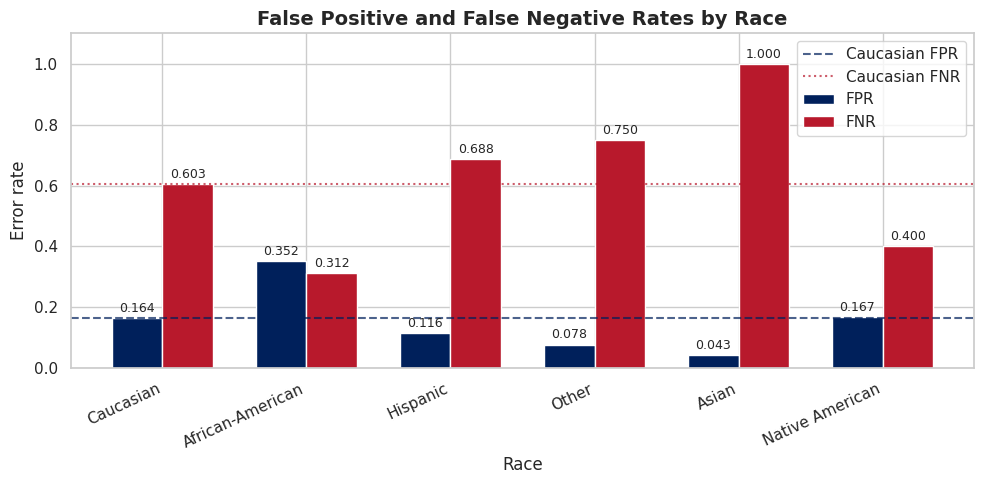

In [49]:
sns.set_theme(style="whitegrid")

order = ["Caucasian", "African-American", "Hispanic", "Other", "Asian", "Native American"]
order = [r for r in order if r in race_metrics_hw3["race_factor"].tolist()]

plot_df = race_metrics_hw3.copy()
plot_df["race_factor"] = pd.Categorical(plot_df["race_factor"], categories=order, ordered=True)
plot_df = plot_df.sort_values("race_factor")

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(plot_df))
width = 0.35

bars1 = ax.bar(x - width/2, plot_df["FPR"], width, label="FPR", color="#00205B")
bars2 = ax.bar(x + width/2, plot_df["FNR"], width, label="FNR", color="#B8192C")

ax.axhline(ref_fpr, color="#00205B", linestyle="--", linewidth=1.5, alpha=0.7, label="Caucasian FPR")
ax.axhline(ref_fnr, color="#B8192C", linestyle=":", linewidth=1.5, alpha=0.7, label="Caucasian FNR")

ax.set_title("False Positive and False Negative Rates by Race", fontsize=14, weight="bold")
ax.set_xlabel("Race")
ax.set_ylabel("Error rate")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["race_factor"], rotation=25, ha="right")
ax.set_ylim(0, max(plot_df[["FPR", "FNR"]].max()) + 0.10)
ax.legend(frameon=True)

for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("fpr_fnr_by_race_hw3.png", dpi=300, bbox_inches="tight")
plt.show()